# Dynamo on Azure AKS - KV Router

## Overview
End-to-end runbook to provision an AKS cluster, deploy the NVIDIA Dynamo inference platform, and enable KV-Cache routing. 

## Results preview
Using 6 NC-H100 GPUs with horizontal scaling, KV-routing shows a clear improvement in both latency and throughput compared to the non–KV-routing setup. With KV-routing enabled, the average time to first token drops significantly (≈1.5s vs ≈18.8s), and overall request latency improves by nearly 3× (≈11s vs ≈30s). 

At the same time, system throughput increases, with output token throughput rising from ~1,750 tokens/sec to ~2,066 tokens/sec and request throughput increasing from ~9.7 to ~11.5 requests/sec. 

These results highlight how KV-routing effectively reuses cached attention states across GPUs, reducing recomputation, improving tail latency (p99), and enabling more efficient scaling—leading to faster responses and higher utilization of GPU resources in distributed inference.


## Prerequisites
- Azure CLI installed and Managed Identity / service principal with `Contributor` on the target resource group
- GPU quota for `Standard_NC40ads_H100_v5` or other GPU VMs

## Steps

| Step | Description |
|------|-------------|
| 1 | Environment Configuration |
| 2 | Provision AKS Cluster & GPU Node Pool |
| 3 | Install Cluster Tooling (kubectl, Helm, GPU Operator) |
| 4 | Install NVIDIA Dynamo Platform |
| 5 | Deploy LLM Inference Workload |
| 6 | Expose the Frontend Service |
| 7 | Smoke Test & Load-Driven Autoscaling Validation |
| 8 | Experiment settings & Results  |
| 9 | Azure Managed Grafana Dashboard for VLLM |


In [ ]:
%%bash
# Upgrade Azure CLI to the latest release.
# This ensures the aks, acr, and monitor sub-commands used throughout this notebook are available.
az upgrade --yes

In [ ]:
%%bash
# Log in using the managed identity attached to this compute instance.
# If running locally, replace with:  az login  (interactive browser flow)
az login --identity

## 1) Environment Configuration

Set all cluster parameters in one cell before running any provisioning steps. Update these values to match your Azure subscription.

In [ ]:
import os

# ── Cluster Identity ──────────────────────────────────────────────────────────
os.environ["RESOURCE_GROUP"] = "aks_dynamo"  # Resource group name
os.environ["REGION"]         = "spaincentral"           # Azure region
os.environ["ZONE"]           = "1"                       # Availability zone (check GPU quota first)
os.environ["CLUSTER_NAME"]  = "dynamo-cluster"          # AKS cluster name

# ── Node Pool Sizing ──────────────────────────────────────────────────────────
# CPU_COUNT: system node pool size (runs kube-system)
os.environ["CPU_COUNT"]       = "1"

# GPU node pool
os.environ["AKS_NODE_COUNT"]   = "3"

# standard_nc80adis_h100_v5 (2x H100)
os.environ["AKS_NODE_VM_SIZE"] = "standard_nc80adis_h100_v5"

## 2) Provision AKS Cluster & GPU Node Pool

Two-step provisioning:
1. **System pool** — lightweight CPU nodes 
2. **GPU pool** (`gpupool`) —

In [ ]:
%%bash
# Create the AKS cluster with the system node pool.
# --enable-azure-monitor-metrics: deploys the AMA agent which config_prome.yaml will configure.
# --enable-node-public-ip: allows direct SSH to nodes for debugging.
az aks create \
  -g $RESOURCE_GROUP \
  -n $CLUSTER_NAME \
  --location $REGION \
  --zones $ZONE \
  --node-count $CPU_COUNT \
  --enable-node-public-ip \
  --generate-ssh-keys \
  --enable-azure-monitor-metrics

**<mark>Before creating the gpu pool, you  need to wait couple minutes so the AKS creation is done and configured.</mark>**

In [ ]:
%%bash
# Add the GPU node pool. You may need to wait couple seconds until the AKS creation is done and configured. 
az aks nodepool add \
  --resource-group $RESOURCE_GROUP \
  --cluster-name $CLUSTER_NAME \
  --name gpupool \
  --node-vm-size $AKS_NODE_VM_SIZE \
  --node-count $AKS_NODE_COUNT \
  --gpu-driver none \
  --enable-node-public-ip


In [ ]:
%%bash
# Login to the cluster
# Merge the AKS kubeconfig into ~/.kube/config.
# --overwrite-existing: safe to re-run if credentials have rotated.
az aks get-credentials --overwrite-existing --resource-group $RESOURCE_GROUP --name $CLUSTER_NAME

## 3) Install Cluster Tooling

- **`kubectl`** — installed here if running in Azure Cloud Shell or a bare Linux VM that may lack it.
- **Helm 3** — required for all platform charts (GPU Operator, Prometheus, Dynamo, KEDA).
- **NVIDIA GPU Operator** — installed immediately after Helm, before any workloads, so that GPU nodes initialise drivers and device plugins before Dynamo pods schedule onto them.

In [ ]:
%%bash
# Install kubectl if not already present (required in Azure Cloud Shell and bare Linux VMs).
sudo apt-get update -qq && sudo apt-get install -y kubectl

In [ ]:
%%bash
# Install Helm 3 via the official bootstrap script.
# Required for GPU Operator, Prometheus, Dynamo, and KEDA Helm charts.
curl https://raw.githubusercontent.com/helm/helm/main/scripts/get-helm-3 | bash

In [ ]:
%%bash
# Install the NVIDIA GPU Operator into the gpu-operator namespace.
# The operator installs the CUDA driver, container toolkit, device plugin, and DCGM exporter
# on nodes that carry the gpu-driver=none label set during nodepool creation.
helm repo add nvidia https://helm.ngc.nvidia.com/nvidia --pass-credentials
helm repo update
helm install --create-namespace --namespace gpu-operator nvidia/gpu-operator --wait --generate-name

## 4) Install NVIDIA Dynamo Platform

After installation, verify all pods in `dynamo-system` are `Running` before deploying the inference workload.

In [ ]:
%%bash
export NAMESPACE=dynamo-system  # don't change
export RELEASE_VERSION=1.0.2

helm fetch https://helm.ngc.nvidia.com/nvidia/ai-dynamo/charts/dynamo-platform-${RELEASE_VERSION}.tgz
helm install dynamo-platform dynamo-platform-${RELEASE_VERSION}.tgz \
  --namespace ${NAMESPACE} \
  --create-namespace

In [ ]:
%%bash
# Verify all Dynamo platform pods are completed or Ready before proceeding.
# Expected pods: dynamo-operator, dynamo-controller, and supporting services.
export NAMESPACE=dynamo-system
kubectl get pods -n $NAMESPACE

**<mark>Make sure all pods are Ready before proceeding </mark>**

### Apply Azure Monitor Prometheus Scraping Config
**`config_prome.yaml`** (`ConfigMap` → `kube-system/ama-metrics-settings-configmap`):
- Applies to the Azure Monitor Metrics agent (AMA), configuring which scrapers are enabled.
- Crucially enables **pod-annotation-based scraping** scoped to the `dynamo-cloud` namespace:
  ```
  podannotationnamespaceregex = "dynamo-cloud"
  ```
- This causes the AMA agent to discover and scrape pods that carry `prometheus.io/scrape: "true"` annotations

In [ ]:
%%bash
# Apply the Azure Monitor Managed Prometheus configuration (ConfigMap in kube-system).
# Key settings in config_prome.yaml:
#   - pod-annotation-based scraping scoped to the 'dynamo-cloud' namespace
#   - cadvisor, kubestate, nodeexporter enabled at 30 s intervals
#   - dcgmexporter disabled (GPU metrics come via DCGM inside the GPU Operator instead)
kubectl apply -f ./config_prome.yaml

## 5) Deploy LLM Inference Workload


In [ ]:
%%bash
# Create the inference workload namespace.
export HF_TOKEN="<Your HF TOKEN>" 
export CLOUD_NAMESPACE=dynamo-cloud   # or your preferred name
kubectl create namespace "${CLOUD_NAMESPACE}"

kubectl create secret generic hf-token-secret \
  --from-literal=HF_TOKEN="${HF_TOKEN}" \
  -n "${CLOUD_NAMESPACE}"


In [ ]:
%%bash
# With KV Routing
kubectl apply -f ./deploy.yaml -n dynamo-cloud

# No KV Routing if you want to benchmark 
# kubectl apply -f ./deploy-no-kv-routing.yaml -n dynamo-cloud

In [ ]:
%%bash
# Wait for Frontend and VllmDecodeWorker pods to reach Running state.
# Expected: 2x *-frontend, 6x *-vllmdecodeworker
export NAMESPACE=dynamo-cloud
kubectl get pods -n $NAMESPACE

**<mark>Make sure all pods are Ready before going to next </mark>**


**<mark>Some pods may go into CrashLoop couple times because downloading all the model files is rate-limited by HuggingFace </mark>**

## 6) Expose the Frontend Service

Patch `*-frontend` from `ClusterIP` to `LoadBalancer`. Azure provisions a public IP and routes traffic on port **8000** to the Frontend pods, which expose the OpenAI-compatible `/v1/chat/completions` API.

> Wait until `kubectl get svc` shows a real IP in `EXTERNAL-IP` (not `<pending>`) before running the smoke test. This typically takes 1–2 minutes.

In [ ]:
%%bash
# Patch the Frontend service from ClusterIP to LoadBalancer.
# This provisions an Azure public load balancer on port 8000 routed to the Frontend pods.
# The endpoint exposes the OpenAI-compatible /v1/chat/completions API.
export NAMESPACE=dynamo-cloud
kubectl patch svc agg-frontend -n ${NAMESPACE} \
  -p '{"spec":{"type":"LoadBalancer","ports":[{"port":8000,"targetPort":8000}]}}'

## 7) Smoke Test 

**Smoke test** — single `curl` to the OpenAI-compatible `/v1/chat/completions` endpoint, confirming the service is reachable and Qwen/Qwen3-0.6B is loaded.


In [ ]:
%%bash
# Get the external IP assigned by Azure to the LoadBalancer.
# Wait until EXTERNAL-IP is no longer '<pending>' before running the smoke test.
# Provisioning typically takes 1-2 minutes.
export NAMESPACE=dynamo-cloud
kubectl get svc agg-frontend -n ${NAMESPACE}

In [ ]:
%%bash
# Smoke test: single chat completion request to confirm the endpoint and model are ready.
# Expected: JSON response with a 'choices' array containing the model's reply.
# Use the External IP.

export EXTERNAL_IP=<Your IP>


curl http://$EXTERNAL_IP:8000/v1/chat/completions \
  -H "Content-Type: application/json" \
  -d '{
    "model": "Qwen/Qwen3-8B-FP8",
    "messages": [
      {
        "role": "user",
        "content": [{ "type": "text", "text": "hi? hello" }]
      }
    ],
    "stream": false
  }'

### Load-Test Validation for KV-Cache-routing

In [ ]:
# Install aiperf — NVIDIA's LLM inference performance profiler.
# Provides request-level latency (TTFT, TPOT, E2E), throughput, and token stats.
!pip install aiperf

**<mark>Run this in the terminal</mark>**

In [ ]:
%%bash
# Load test: 

# AIPERF_SERVICE_PROFILE_START_TIMEOUT controls how long aiperf waits for the service to appear.
export AIPERF_SERVICE_PROFILE_START_TIMEOUT=30000
export EXTERNAL_IP=<Your IP>


aiperf profile \
  --model Qwen/Qwen3-8B-FP8 \
  --tokenizer Qwen/Qwen3-8B-FP8 \
  --input-file toolagent_trace.jsonl \
  --endpoint-type chat \
  --url $EXTERNAL_IP:8000 \
  --streaming \
  --request-rate 12.0 \
  --request-count 6480 \
  --num-dataset-entries 18000 \
  --artifact-dir /tmp/scaling_test_phase2_extended

## 8- Experiment Settings & Results

Experiemnt Settings:

- **Hardware:** 6× NC‑H100 GPUs (horizontal scaling)
- **Model:** Qwen/Qwen3‑8B‑FP8
- **Workload:** (18,000 dataset entries)
- **Load Profile:** 12 req/sec, 6,480 total requests
- **Mode:** Streaming (chat endpoint)
- **Dataset:** traces published with Mooncake—the serving stack behind Kimi (Moonshot AI). For the FAST'25 paper, the project released FAST25-release/traces/, including toolagent_trace.jsonl



| Metric                    | No KV-Routing | KV-Routing  | Improvement   |
| ------------------------- | ------------- | ----------- | ------------- |
| Time to First Token (avg) | 18.8 s        | 1.5 s       | **↓ \~91.8%** |
| Request Latency (avg)     | 30.9 s        | 11 s        | **↓ \~64.3%** |
| Output Token Throughput   | 1,750 tok/s   | 2,066 tok/s | **↑ \~18.0%** |
| Request Throughput        | 9.73 req/s    | 11.48 req/s | **↑ \~18.0%** |

**Key takeaway:** KV-routing delivers **massive latency reductions (up to \~92%)** while also **boosting throughput \~18%**, demonstrating significantly better scaling efficiency and GPU utilization.


## 9- Azure Managed Grafana Dashborad 

From the AKS cluster view on Azure portal (`Dashboards with Grafana section`) - check the screenshot -   add and import VLLM Grafana dashboard for monitoring. This dashboard is designed to visualize key performance metrics of the VLLM model deployments, such as latency, throughput, and resource utilization.


Json Grafana dashboard file to import:
https://grafana.com/grafana/dashboards/24756-vllm-monitoring-v2/


![vllm dashboard](./img/vllm_dashboard.png)
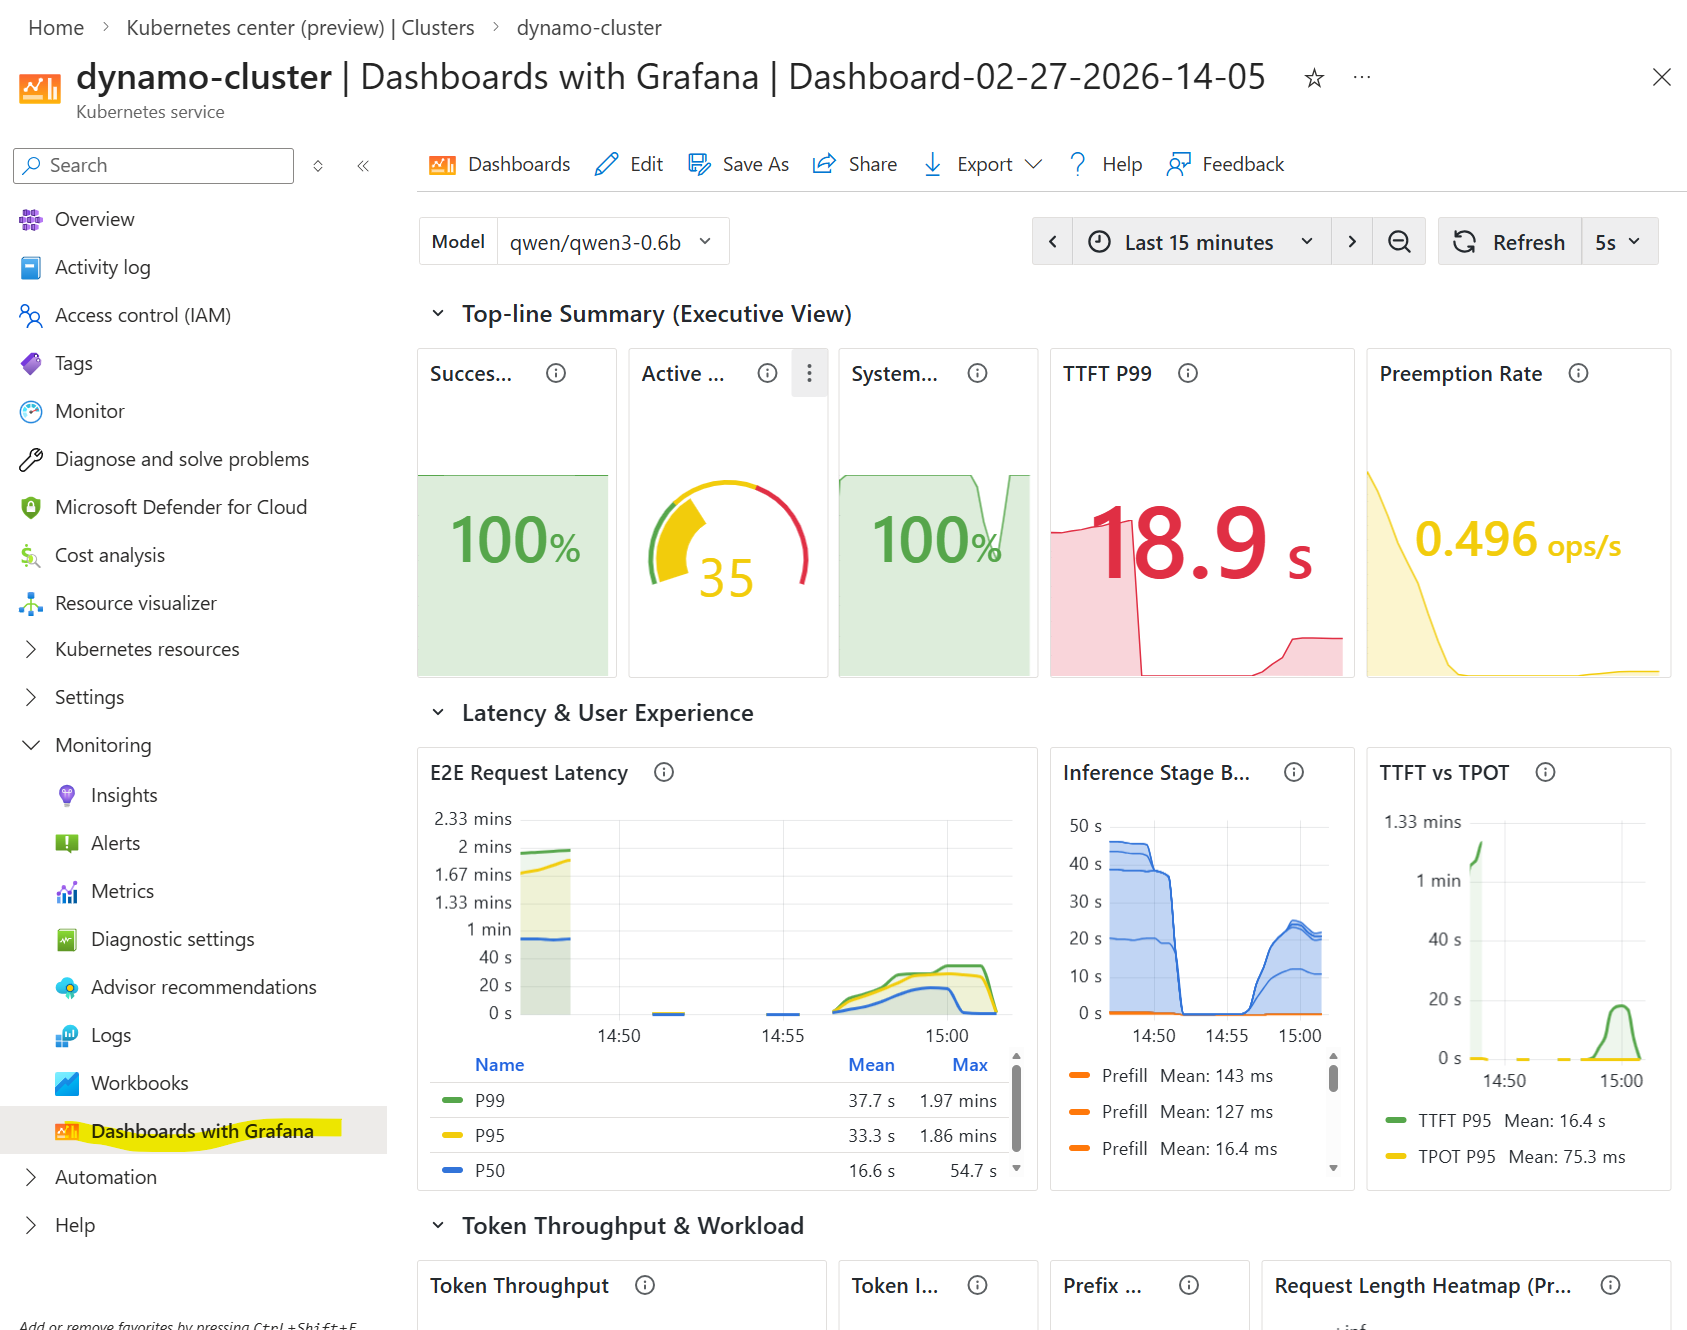